# EDA — Validaciones TransMilenio (UrbanSafe AI)

Análisis exploratorio del dataset procesado `dataset.csv` (y su muestra de 100 filas).

**Convención de columnas:** cada fila = total de validaciones (pasajeros que entran)
de una **línea** en una **estación**, en una **hora** de un día concreto.

Fuente: Portal de Datos Abiertos de TransMilenio. Documento completo: `deliveries/week05/DATA_DICTIONARY.md`.

In [1]:
# ============ 1. Carga de datos ============
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="viridis")

# Dataset completo + muestra de ejemplo
FULL = Path("data/transmilenio/dataset.csv")
SAMP = Path("data/transmilenio/dataset_sample100.csv")

df = pd.read_csv(FULL if FULL.exists() else SAMP, dtype={"Hora": str})
muestra = pd.read_csv(SAMP if SAMP.exists() else FULL, dtype={"Hora": str})     if SAMP.exists() else df.sample(100, random_state=42)

df["Fecha"] = pd.to_datetime(df["Fecha"])
df["DiaSemana"] = df["Fecha"].dt.day_name()
df["HoraInt"] = df["Hora"].str.zfill(2).str[:2].astype(int)

print(f"Completo: {df.shape[0]:,} filas | {df['Estacion'].nunique()} estaciones | "
      f"{df['Fecha'].nunique()} días | {df['Linea'].nunique()} líneas")
print(f"Muestra de ejemplo: {muestra.shape[0]} filas")
print("\nColumnas:", ", ".join(df.columns))

Completo: 192,510 filas | 156 estaciones | 69 días | 13 líneas
Muestra de ejemplo: 100 filas

Columnas: Estacion, Latitud, Longitud, Ubicacion, Troncal, Fase, Cap_ART, Cap_BIART, Fecha, Hora, Linea, Tipo_Dia, Validaciones, DiaSemana, HoraInt


## 2. Vista rápida de los datos
Primeras filas, tipos y estadística descriptiva básica.

In [2]:
# ============ 2. Vista rápida ============
print("--- Muestra (primeras 5 filas) ---")
print(muestra.head().to_string(index=False))

print("\n--- Tipos de columna ---")
print(df.dtypes)

print("\n--- Estadística validaciones ---")
print(df["Validaciones"].describe().round(1))

--- Muestra (primeras 5 filas) ---
                            Estacion  Latitud   Longitud       Ubicacion         Troncal     Fase  Cap_ART  Cap_BIART      Fecha Hora                 Linea Tipo_Dia  Validaciones
       (02303) Calle 85 - GATO DUMAS 4.672313 -74.059644           CL 85 Autopista Norte   FASE I    200.0      120.0 2026-08-09   21 (33) Zona B AutoNorte    Dia 2            33
                    (12003) Ricaurte 4.612681 -74.090092   CL 13 - KR 28        Americas  FASE II    192.0      120.0 2026-07-05   14  (39) Zona F Calle 13    Dia 2            91
    (06100) Av. Rojas – UNISALESIANA 4.661944 -74.108772 CL 26 - KR 69 D        Calle 26 FASE III    200.0      120.0 2026-07-05   14  (11) Zona K Calle 26    Dia 2           140
           (09129) Temporal Calle 22      NaN        NaN             NaN             NaN      NaN      NaN        NaN 2026-07-17   13   (36) Zona A Caracas    Dia 1           293
(02204) Pepe Sierra Universidad UTEL 4.698127 -74.055309          CL 1

## 3. Validaciones por hora del día
¿El dataset captura los picos de demanda esperados (mañana y tarde)?

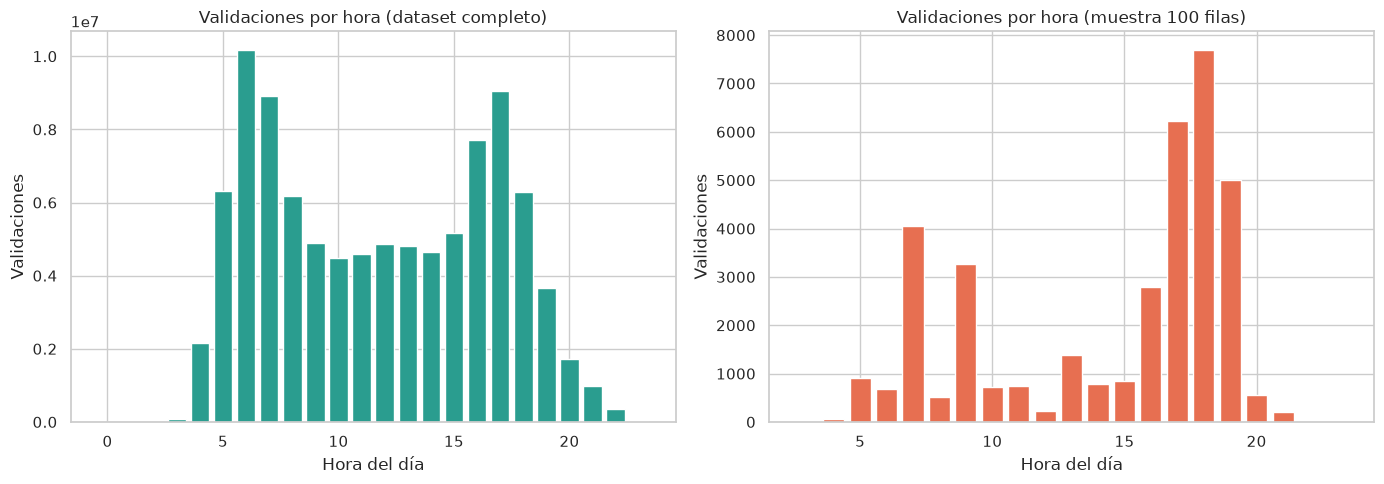

In [3]:
# ============ 3. Perfil horario de demanda ============
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

hora = df.groupby("HoraInt")["Validaciones"].sum()
ax[0].bar(hora.index, hora.values, color="#2a9d8f")
ax[0].set_title("Validaciones por hora (dataset completo)")
ax[0].set_xlabel("Hora del día"); ax[0].set_ylabel("Validaciones")

hora_m = muestra.groupby(muestra["Hora"].str.zfill(2).str[:2].astype(int))["Validaciones"].sum()
ax[1].bar(hora_m.index, hora_m.values, color="#e76f51")
ax[1].set_title("Validaciones por hora (muestra 100 filas)")
ax[1].set_xlabel("Hora del día"); ax[1].set_ylabel("Validaciones")

plt.tight_layout(); plt.show()

## 4. Validaciones por día de la semana



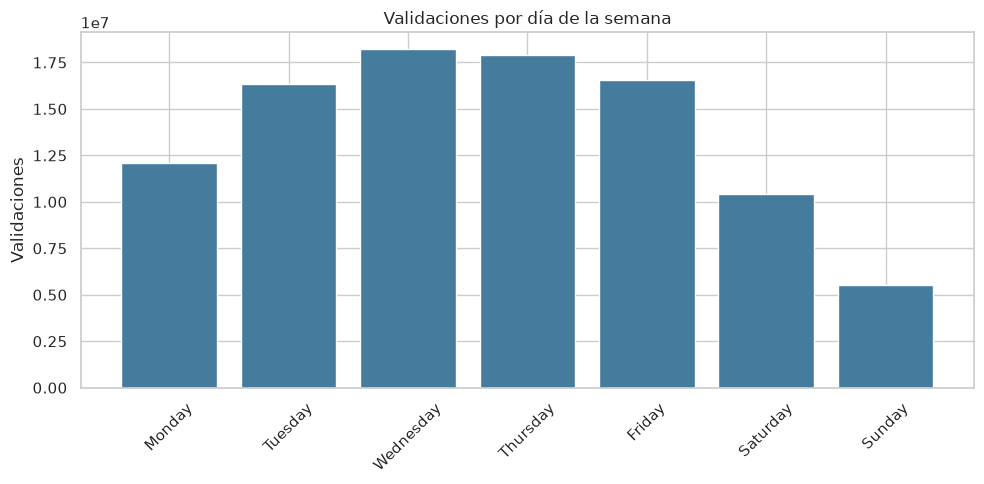

Fecha
Monday       12087973
Tuesday      16342933
Wednesday    18212643
Thursday     17908951
Friday       16576330
Saturday     10403052
Sunday        5533203


In [4]:
# ============ 4. Validaciones por día de la semana ============
por_dia = df.groupby(df["Fecha"].dt.day_name())["Validaciones"].sum().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(10, 5))
plt.bar(por_dia.index, por_dia.values, color="#457b9d")
plt.title("Validaciones por día de la semana")
plt.xticks(rotation=45)
plt.ylabel("Validaciones")
plt.tight_layout(); plt.show()
print(por_dia.round(0).to_string())


## 5. Estaciones más transitadas (Top 10)
Las estaciones de mayor demanda por Tipo de Día.

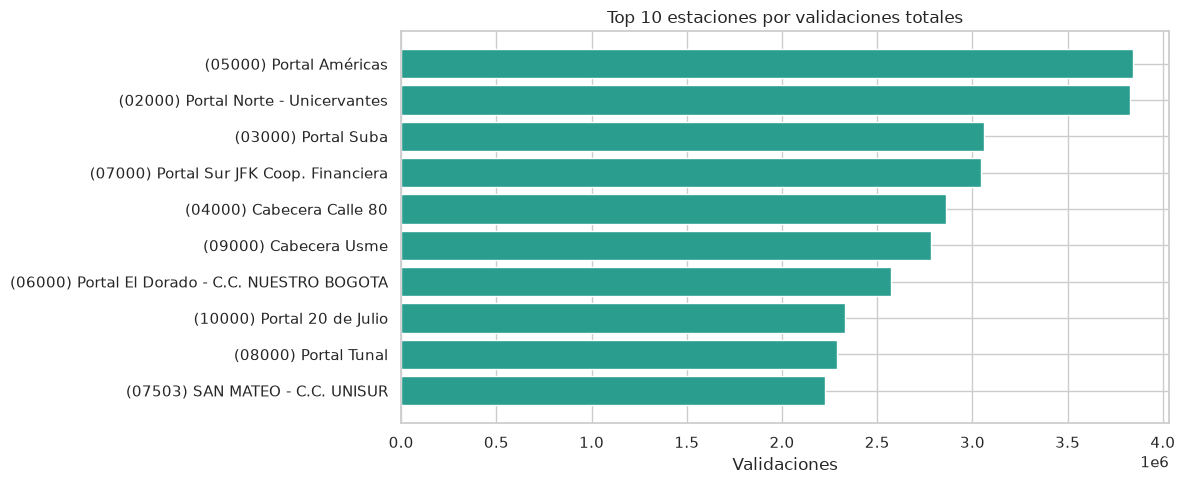

Estacion
(05000) Portal Américas                           3841575
(02000) Portal Norte - Unicervantes               3829308
(03000) Portal Suba                               3062356
(07000) Portal Sur JFK Coop. Financiera           3047011
(04000) Cabecera Calle 80                         2863770
(09000) Cabecera Usme                             2784404
(06000) Portal El Dorado - C.C. NUESTRO BOGOTA    2570791
(10000) Portal 20 de Julio                        2332743
(08000) Portal Tunal                              2287536
(07503) SAN MATEO - C.C. UNISUR                   2224137


In [5]:
# ============ 5. Top estaciones ============
top = df.groupby("Estacion")["Validaciones"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top.index[::-1], top.values[::-1], color="#2a9d8f")
ax.set_title("Top 10 estaciones por validaciones totales")
ax.set_xlabel("Validaciones")
plt.tight_layout(); plt.show()
print(top.round(0).to_string())

## 6. Líneas (agrupaciones de rutas) más usadas

`Linea` es la clave más fina disponible: agrupa varias **rutas** de bus que comparten la misma
**zona de operación** (p.ej. `(33) Zona B AutoNorte` = código `33`, zona `B`, troncal `Autopista Norte`).
La ruta individual (`Ruta`) viene vacía en la fuente, por eso agregamos por línea.


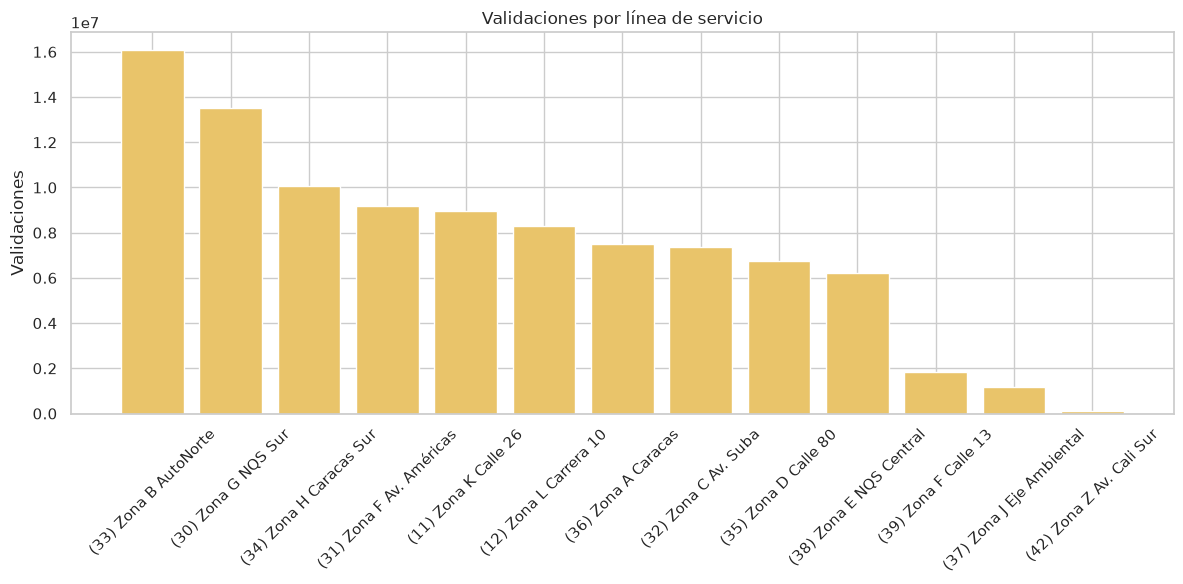

13 líneas en total.
Linea
(33) Zona B AutoNorte        16060713
(30) Zona G NQS Sur          13515203
(34) Zona H Caracas Sur      10066010
(31) Zona F Av. Américas      9169131
(11) Zona K Calle 26          8976346
(12) Zona L Carrera 10        8297817
(36) Zona A Caracas           7520769
(32) Zona C Av. Suba          7356694
(35) Zona D Calle 80          6761540
(38) Zona E NQS Central       6231795
(39) Zona F Calle 13          1819524
(37) Zona J Eje Ambiental     1164431
(42) Zona Z Av. Cali Sur       125112


In [6]:
# ============ 6. Líneas más usadas ============
lineas = df.groupby("Linea")["Validaciones"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(lineas.index, lineas.values, color="#e9c46a")
ax.set_title("Validaciones por línea de servicio")
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Validaciones")
plt.tight_layout(); plt.show()
print(f"{len(lineas)} líneas en total.")
print(lineas.round(0).to_string())

## 7. Mapa: análisis geoespacial con OpenStreetMap + rutas TransMilenio

En el capítulo el mapa de tiles de OSM falla (acceso bloqueado). Alternativa del laboratorio:
descargar **datos vectoriales reales de OSM** con `pyrosm` (edificios y red vial de Bogotá)
y dibujarlos con `geopandas`/`folium` — sin depender del servidor de tiles.

**Convenciones del mapa:**
- **Puntos negros** = estaciones de TransMilenio, con tamaño ∝ demanda acumulada.
- **Líneas de color** = trazados con demanda (color/grosor ∝ validaciones).
- **Líneas gris punteadas** = proyecciones futuras sin estaciones ni demanda (aún no operan).

**Cruce robusto estación→trazado:** se une por **código** `num_est` con fallback por **nombre**
normalizado, porque el geojson de estaciones trae códigos viejos (ej. `5009`) que el dataset
actualizó (ej. `15001` Tibanica); sin ese fallback esos trazados aparecerían con 0 demanda.

1. `get_data("Bogota")` → extracto OSM de Geofabrik (`.osm.pbf`).
2. `OSM(pbf).get_network()` y `.get_buildings()` → red vial y edificios.
3. Superponer los **trazados de TransMilenio** con color y grosor ∝ demanda acumulada
   y las estaciones como puntos ∝ demanda.

Extracto OSM: 20.3 MB


Vías OSM: 53,297 | Edificios OSM: 134,057
Estaciones geo con demanda asignada: 146/156


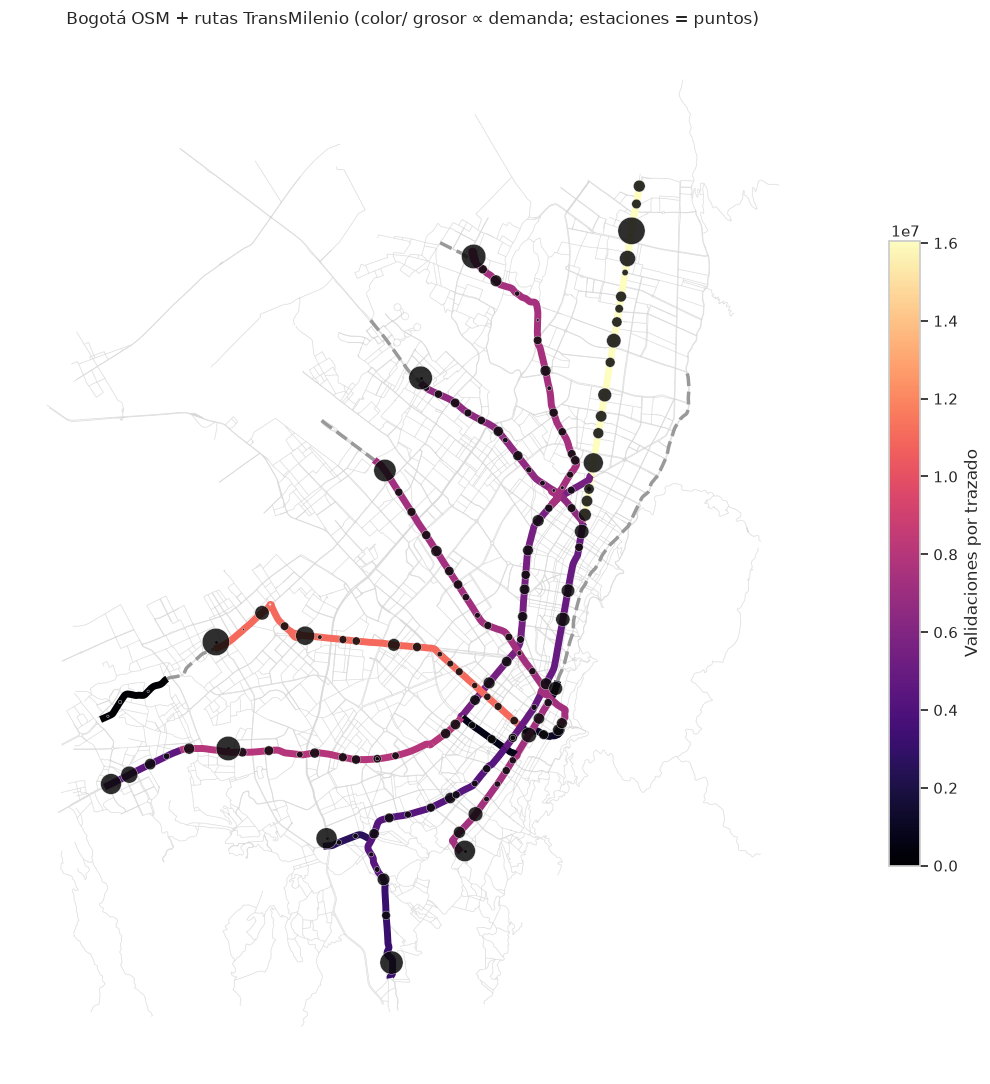

Trazados con demanda: 17/22
Proyecciones futuras sin demanda: 5
   TZ004: Suba (Portal Suba -> Avenida ALO)
   TZ020: Carrera 7 (Museo Nacional -> Avenida Calle 134)
   TZ017: Calle 26 (Portal Eldorado -> Aeropuerto El Dorado)
   TZ006: Calle 80 (Portal 80 -> Limite del Distrito)
   TZ022A: Avenida Ciudad de Cali (Portal Américas -> Tibanica)


In [7]:
# ============ 7. Mapa: OSM (pyrosm) + trazados TransMilenio ============
import unicodedata
import geopandas as gpd
import contextily as cx
from pyrosm import OSM, get_data

def norm(s):
    s = str(s).strip().upper()
    t = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in t if not unicodedata.combining(ch)).replace("'", "")

GEO = Path("data/transmilenio/geo")
PBF = GEO / "bogota.osm.pbf"

# --- 1) Datos reales de OpenStreetMap para Bogotá (una vez) ---
if not PBF.exists():
    src = get_data("Bogota")
    src.replace(PBF)
print(f"Extracto OSM: {PBF.stat().st_size/1e6:.1f} MB")
osm = OSM(PBF)

# --- 2) Red vial y edificios de OSM ---
roads = osm.get_network("driving")           # 53k vías
buildings = osm.get_buildings()              # 134k edificios
print(f"Vías OSM: {len(roads):,} | Edificios OSM: {len(buildings):,}")

# --- 3) Demanda por estación, con cruce ROBUSTO (código + nombre) ---
uso = df.groupby("Estacion", as_index=False)["Validaciones"].sum()
uso["num_est"] = uso["Estacion"].str.extract(r"^\((\d+)\)")
uso["nom_l"] = uso["Estacion"].str.replace(r"^\((\d+)\s?\)\s*", "", regex=True).map(norm)

estaciones = gpd.read_file(GEO / "estaciones_troncales.geojson")
estaciones["num_est"] = estaciones["num_est"].astype(str).str.zfill(5)
estaciones["nom_l"] = estaciones["nom_est"].map(norm)

# match por código primero, luego por nombre normalizado (hay códigos viejos en el geojson)
m = estaciones.merge(uso[["num_est", "Validaciones"]], on="num_est", how="left", suffixes=("", "_cod"))
uso_nom = dict(zip(uso["nom_l"], uso["Validaciones"]))
m["Val"] = m["Validaciones"].fillna(m["nom_l"].map(uso_nom))
print(f"Estaciones geo con demanda asignada: {m['Val'].notna().sum():,}/{len(m):,}")

# demanda por trazado
dem_traz = m.groupby("id_trazado", as_index=False)["Val"].sum().rename(columns={"Val": "Validaciones"})
trazados = gpd.read_file(GEO / "trazados_troncales.geojson").merge(
    dem_traz, on="id_trazado", how="left")

con_dem = trazados.dropna(subset=["Validaciones"])
sin_dem = trazados[trazados["Validaciones"].isna()]      # proyecciones futuras

# --- 4) Mapa estático: Bogotá OSM + rutas TM con demanda ---
fig, ax = plt.subplots(figsize=(15, 11))
principales = roads[roads["highway"].isin(["trunk", "primary", "secondary", "tertiary"])]
principales.plot(ax=ax, color="#d9d9d9", linewidth=0.5)

# Ext. futuras sin demanda: gris punteado (no confundir con "0")
sin_dem.plot(ax=ax, color="#999999", linewidth=2.5, linestyle="--")

# Trazados con demanda: color magma (0 ya no es negro por el cruce corregido)
con_dem.plot(ax=ax, column="Validaciones", cmap="magma", linewidth=5,
             legend=True, legend_kwds={"label": "Validaciones por trazado", "shrink": 0.6}, vmin=0)

# Estaciones = puntos negros (tamaño ∝ demanda)
est_pts = m.dropna(subset=["Val"]).copy()
est_pts["s"] = (est_pts["Val"] / 1e4).clip(2, 500)
est_pts.plot(ax=ax, marker="o", markersize=1, color="#0a0a0a")
ax.scatter(est_pts.geometry.x, est_pts.geometry.y, s=est_pts["s"], c="#0a0a0a",
           alpha=0.85, edgecolors="white", linewidths=0.3, zorder=5)
ax.set_title("Bogotá OSM + rutas TransMilenio (color/ grosor ∝ demanda; estaciones = puntos)")
ax.set_axis_off()
plt.tight_layout(); plt.show()

print(f"Trazados con demanda: {len(con_dem)}/{len(trazados)}")
print(f"Proyecciones futuras sin demanda: {len(sin_dem)}")
for _, r in sin_dem.iterrows():
    print(f"   {r['id_trazado']}: {r['nom_tronc']} ({r['ori_traz']} -> {r['fin_traz']})")


In [8]:
# ============ 7b. Mapa interactivo con folium ============
import folium
import mapclassify
import branca.colormap as cm

# Estaciones con demanda (misma fusión robusta de la sección 7)
pts = m.dropna(subset=["Val"]).copy()
pts["Tam"] = (pts["Val"] / 1e4).clip(2, 18).round(1) + 3

vmin, vmax = 0.0, pts["Val"].max()
colormap = cm.LinearColormap(["#f7fbff", "#6baed6", "#08519c"], vmin=vmin, vmax=vmax)

m = folium.Map(location=[4.653, -74.083], zoom_start=12,
               tiles="CartoDB Positron", attr="CartoDB")  # tiles alternativo (sin bloqueo)

# Estaciones: círculos negros con popup de demanda
for _, r in pts.iterrows():
    folium.CircleMarker(
        location=[r.geometry.y, r.geometry.x], radius=r["Tam"],
        color="black", weight=0.6, fill=True,
        fill_color=colormap(r["Val"]), fill_opacity=0.8,
        popup=f"<b>{r['nom_est']}</b><br>Validaciones: {r['Val']:,.0f}",
        tooltip=r["nom_est"],
    ).add_to(m)

# Trazados con demanda: línea coloreada por % de demanda
traz_fol = trazados.dropna(subset=["Validaciones"]).copy()
traz_fol["Validaciones"] = traz_fol["Validaciones"].fillna(0)
traz_fol = traz_fol.to_crs(epsg=4326)
for _, r in traz_fol.iterrows():
    color = colormap(r["Validaciones"])
    if r.geometry.geom_type == "LineString":
        parts = [list(r.geometry.coords)]
    else:  # MultiLineString
        parts = [list(g.coords) for g in r.geometry.geoms]
    for part in parts:
        coords = [[c[1], c[0]] for c in part]
        folium.PolyLine(coords, color=color, weight=5, opacity=0.9,
                        tooltip=f"{r['nom_tronc']}: {r['Validaciones']:,.0f}").add_to(m)

# Proyecciones futuras: gris punteado
sin_fol = trazados[trazados["Validaciones"].isna()].to_crs(epsg=4326)
for _, r in sin_fol.iterrows():
    if r.geometry.geom_type == "LineString":
        parts = [list(r.geometry.coords)]
    else:
        parts = [list(g.coords) for g in r.geometry.geoms]
    for part in parts:
        coords = [[c[1], c[0]] for c in part]
        folium.PolyLine(coords, color="#777777", weight=2.5, opacity=0.6, dash_array="6, 4",
                        tooltip=f"{r['nom_tronc']} (proyección)").add_to(m)

colormap.add_to(m)
m


## 7b. Mapa interactivo (folium)

Versión navegable con `folium`: las estaciones se abren con un popup con su demanda,
y los trazados se colorean por demanda con `mapclassify` (esquema `NaturalBreaks`).

## 8. Matriz de correlación de variables numéricas

Capacidades, coordenadas y demanda: ¿hay correlaciones útiles para el modelo?

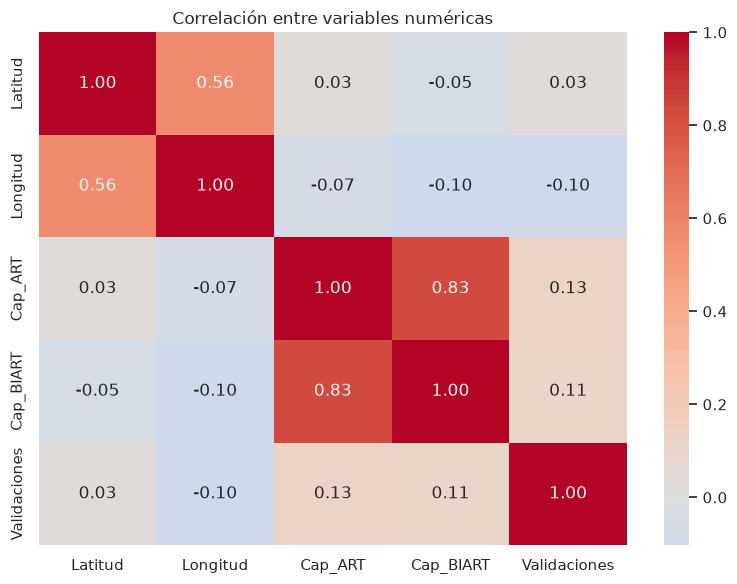

In [9]:
# ============ 8. Correlaciones ============
num_cols = ["Latitud", "Longitud", "Cap_ART", "Cap_BIART", "Validaciones"]
aux_num = pd.read_csv(FULL, dtype={"Hora": str}) if FULL.exists() else df
corr = aux_num[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout(); plt.show()

## 9. Resumen y verificación de integridad

Comprobaciones: ¿el dataset captura bien estaciones, líneas, ambos tipos de día y cobertura geográfica?

In [10]:
# ============ 9. Resumen de integridad ============
checks = {
    "Estaciones únicas": df["Estacion"].nunique(),
    "Líneas (servicios) únicas": df["Linea"].nunique(),
    "Días cubiertos": df["Fecha"].nunique(),
    "Valor oficial `Dia 1` (hábil)": (df["Tipo_Dia"] == "Dia 1").sum(),
    "Valor oficial `Dia 2` (domingo)": (df["Tipo_Dia"] == "Dia 2").sum(),
    "Filas con coordenadas (lat/lon)": df["Latitud"].notna().sum(),
    "Filas con nombre de Troncal": df["Troncal"].notna().sum() & df["Troncal"].astype(bool).sum(),
    "Filas con Fase asignada": df["Fase"].notna().sum() & df["Fase"].astype(bool).sum(),
    "Total validaciones": df["Validaciones"].sum(),
}
for k, v in checks.items():
    print(f"  {k:<40s}: {v:,}".replace(": ,", ": "))

  Estaciones únicas                       : 156
  Líneas (servicios) únicas               : 13
  Días cubiertos                          : 69
  Valor oficial `Dia 1` (hábil)           : 164,788
  Valor oficial `Dia 2` (domingo)         : 27,722
  Filas con coordenadas (lat/lon)         : 177,970
  Filas con nombre de Troncal             : 173,874
  Filas con Fase asignada                 : 173,874
  Total validaciones                      : 97,065,085
